In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pmdarima as pm

In [2]:
df = pd.read_excel(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\Data_BBCA_2015_sampai_sekarang.xlsx")
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02 00:00:00,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05 00:00:00,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06 00:00:00,2150.688477,2167.105946,2134.271007,2134.271007,48681500


In [3]:
df = df.drop(df.index[0:2])
df.head(10)

,Price,Close,High,Low,Open,Volume
2,2015-01-02 00:00:00,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05 00:00:00,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06 00:00:00,2150.688477,2167.105946,2134.271007,2134.271007,48681500
5,2015-01-07 00:00:00,2154.791992,2167.105089,2142.478895,2142.478895,40334000
6,2015-01-08 00:00:00,2130.166504,2158.897073,2130.166504,2154.792706,54457000
7,2015-01-09 00:00:00,2121.956787,2146.582978,2121.956787,2138.374248,108957500
8,2015-01-12 00:00:00,2134.270508,2134.270508,2101.435577,2121.957409,81651000
9,2015-01-13 00:00:00,2134.270508,2142.479241,2130.166141,2142.479241,36024000
10,2015-01-14 00:00:00,2121.956787,2138.374248,2121.956787,2138.374248,29728000
11,2015-01-15 00:00:00,2126.061279,2142.478741,2126.061279,2126.061279,27580500


In [4]:
df['Price'] = pd.to_datetime(df['Price'])

df = df.rename(columns={'Price': 'Date'})

df = df.sort_values("Date")
df.head()

,Date,Close,High,Low,Open,Volume
2,2015-01-02,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06,2150.688477,2167.105946,2134.271007,2134.271007,48681500
5,2015-01-07,2154.791992,2167.105089,2142.478895,2142.478895,40334000
6,2015-01-08,2130.166504,2158.897073,2130.166504,2154.792706,54457000


In [5]:
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = (
        df[col]
        .astype(str)                     # pastikan string
        .str.replace(',', '', regex=False)  # hapus koma ribuan
        .str.replace(' ', '', regex=False)  # hapus spasi
        .astype(float)                   # ubah ke float
    )

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 2 to 2654
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2653 non-null   datetime64[ns]
 1   Close   2653 non-null   float64       
 2   High    2653 non-null   float64       
 3   Low     2653 non-null   float64       
 4   Open    2653 non-null   float64       
 5   Volume  2653 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 124.5 KB


In [7]:
df = df[['Close']].rename(columns={'Close': 'close'})
df.dropna(inplace=True)
df.head()

,close
2,2171.209473
3,2167.105957
4,2150.688477
5,2154.791992
6,2130.166504


In [8]:
n = len(df)
n_train = int(n * 0.9)
train = df['close'][:n_train]
test = df['close'][n_train:]

print(f"Data total: {n}, Train: {len(train)}, Test: {len(test)}")


Data total: 2653, Train: 2387, Test: 266


In [17]:
result = adfuller(train.dropna(), autolag='AIC')
print("\n=== Uji ADF harga asli ===")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] <= 0.05:
    print("✅ Data stasioner (tolak H0)\n")
    d = 0
else:
    print("❌ Data belum stasioner (gagal tolak H0)\n")
    d = 1



=== Uji ADF harga asli ===
ADF Statistic: 0.4718
p-value: 0.9840
❌ Data belum stasioner (gagal tolak H0)



=== ARIMA pada Harga Asli ===
Order terbaik: (2, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2387
Model:                 ARIMA(2, 1, 0)   Log Likelihood              -13767.870
Date:                Wed, 12 Nov 2025   AIC                          27541.741
Time:                        07:29:23   BIC                          27559.073
Sample:                             0   HQIC                         27548.048
                               - 2387                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1177      0.013     -8.866      0.000      -0.144      -0.092
ar.L2         -0.0573      0.014     -4.018      0.000      -0.085      -0.0

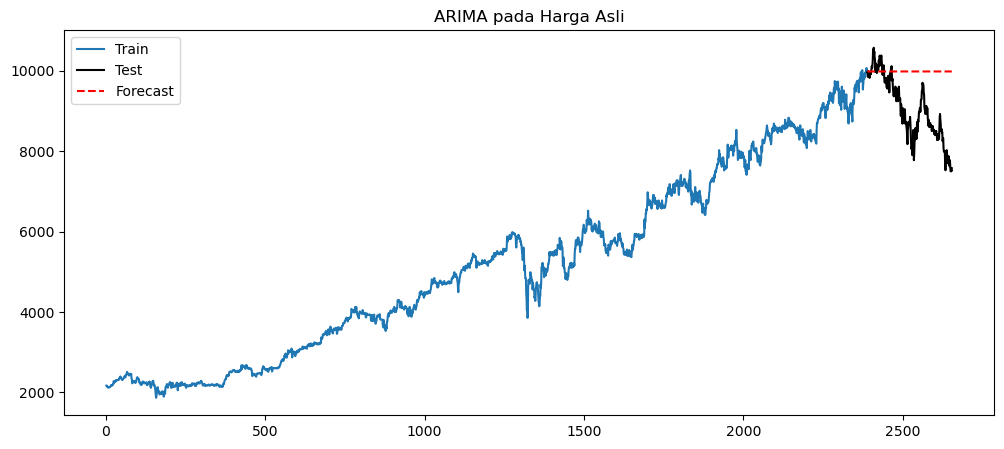

In [19]:
print("=== ARIMA pada Harga Asli ===")
model_auto = pm.auto_arima(train, seasonal=False, d=d, stepwise=True, suppress_warnings=True)
print(f"Order terbaik: {model_auto.order}")

order = model_auto.order
model = ARIMA(train, order=order)
fit = model.fit()
print(fit.summary())

forecast = fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("\nEvaluasi ARIMA Harga Asli:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='black')
plt.plot(forecast.index, forecast, label='Forecast', color='red', linestyle='--')
plt.title('ARIMA pada Harga Asli')
plt.legend()
plt.show()


In [21]:
print("\n=== ARIMA pada Return Harian ===")
df['return'] = df['close'].pct_change()
train_ret = df['return'][:n_train].dropna()
test_ret = df['return'][n_train:].dropna()

result_ret = adfuller(train_ret.dropna(), autolag='AIC')
print(f"ADF Statistic (return): {result_ret[0]:.4f}")
print(f"p-value: {result_ret[1]:.4f}")
if result_ret[1] <= 0.05:
    d_ret = 0
else:
    d_ret = 1

model_auto_ret = pm.auto_arima(train_ret, seasonal=False, d=d_ret, stepwise=True, suppress_warnings=True)
print(f"Order terbaik (return): {model_auto_ret.order}")

model_ret = ARIMA(train_ret, order=model_auto_ret.order)
fit_ret = model_ret.fit()
forecast_ret = fit_ret.forecast(steps=len(test_ret))
forecast_ret = pd.Series(forecast_ret, index=test_ret.index)

# Konversi dari return ke harga
price_pred = [train.iloc[-1]]
for r in forecast_ret:
    price_pred.append(price_pred[-1] * (1 + r))
forecast_price = pd.Series(price_pred[1:], index=test_ret.index)

mae_ret = mean_absolute_error(test.loc[test_ret.index], forecast_price)
rmse_ret = np.sqrt(mean_squared_error(test.loc[test_ret.index], forecast_price))
r2_ret = r2_score(test.loc[test_ret.index], forecast_price)
mape_ret = np.mean(np.abs((test.loc[test_ret.index] - forecast_price) / test.loc[test_ret.index])) * 100

print("\nEvaluasi ARIMA Return Harian:")
print(f"MAE  : {mae_ret:.4f}")
print(f"RMSE : {rmse_ret:.4f}")
print(f"R²   : {r2_ret:.4f}")
print(f"MAPE : {mape_ret:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='black')
plt.plot(forecast_price.index, forecast_price, label='Forecast', color='red', linestyle='--')
plt.title('ARIMA pada Return Harian')
plt.legend()
plt.show()



=== ARIMA pada Return Harian ===
ADF Statistic (return): -22.1813
p-value: 0.0000
Order terbaik (return): (0, 0, 2)


D:\Terminal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Terminal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Terminal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Terminal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


ValueError: Input contains NaN.